<a href="https://colab.research.google.com/github/SwathiSubhasBadiger/Sales-Analysis/blob/main/Product_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Product-Sales-Analysis**

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Upload Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ProductSales.xlsx to ProductSales.xlsx


In [ ]:
df = pd.read_excel("ProductSales.xlsx")
df.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Unnamed: 11,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,NaN,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,NaN,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,NaN,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,NaN,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,NaN,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


**Data Exploration**

In [ ]:
# Dataset Information
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

(1500, 19)
Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Unnamed: 11', 'Returned', 'OrderID', 'CustomerName',
       'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager'],
      dtype='object')
Date             datetime64[ns]
Region                   object
Product                  object
Quantity                  int64
UnitPrice               float64
StoreLocation            object
CustomerType             object
Discount                float64
Salesperson              object
TotalPrice              float64
PaymentMethod            object
Unnamed: 11             float64
Returned                  int64
OrderID                  object
CustomerName             object
ShippingCost            float64
OrderDate        datetime64[ns]
DeliveryDate     datetime64[ns]
RegionManager            object
dtype: object
Date                0
Region              0
Product    

**Data Cleaning**

In [ ]:
# Data Cleaning

df = df.drop_duplicates()

df = df.fillna(0)

print("Duplicates removed and missing values handled successfully!")

Duplicates removed and missing values handled successfully!


**Feature Engineering**

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

df['Month'] = df['OrderDate'].dt.month_name()

print(df[['OrderDate', 'Month']].head())

   OrderDate     Month
0 2023-02-23  February
1 2024-12-19  December
2 2023-05-10       May
3 2025-02-26  February
4 2023-06-24      June


**Top-Product Analysis**

Product
Tablet     2577
Laptop     2408
Printer    2336
Monitor    2177
Chair      2122
Desk       2026
Phone      1970
Name: Quantity, dtype: int64


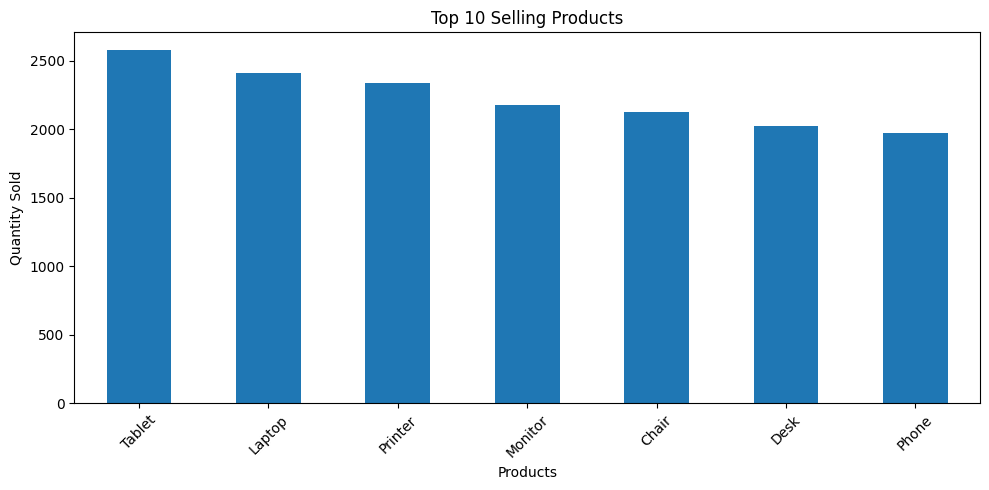

In [ ]:
# Top Products

top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Regional Analysis**

RegionManager
Cameron    847153.6845
Eric       883633.7180
Ryan       967957.9800
Sophie     827768.1870
Wendy      853478.8590
Name: TotalPrice, dtype: float64


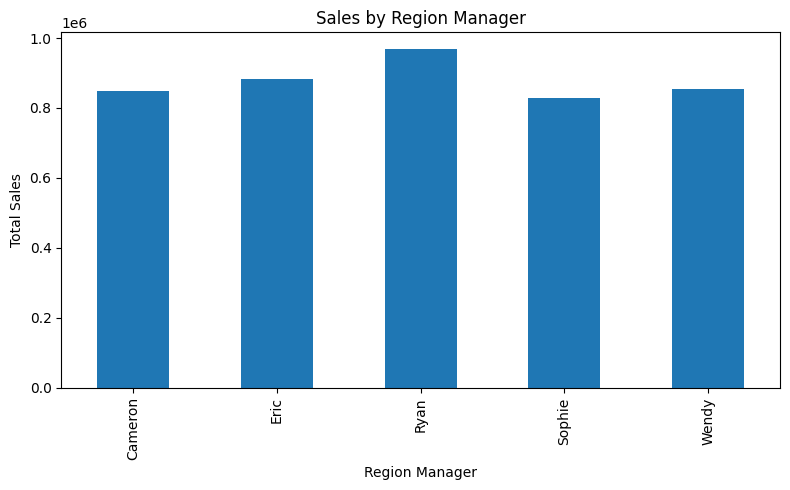

In [ ]:
# Region Sales
region_sales = df.groupby('RegionManager')['TotalPrice'].sum()

print(region_sales)

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales by Region Manager')
plt.xlabel('Region Manager')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

**Monthly Trend Analysis**

Month
April        443318.7265
August       289639.0035
December     262749.5220
February     415057.8135
January      498358.5015
July         280050.0475
June         434261.6690
March        532090.9535
May          402408.0255
November     283330.6200
October      256612.8970
September    282114.6490
Name: TotalPrice, dtype: float64


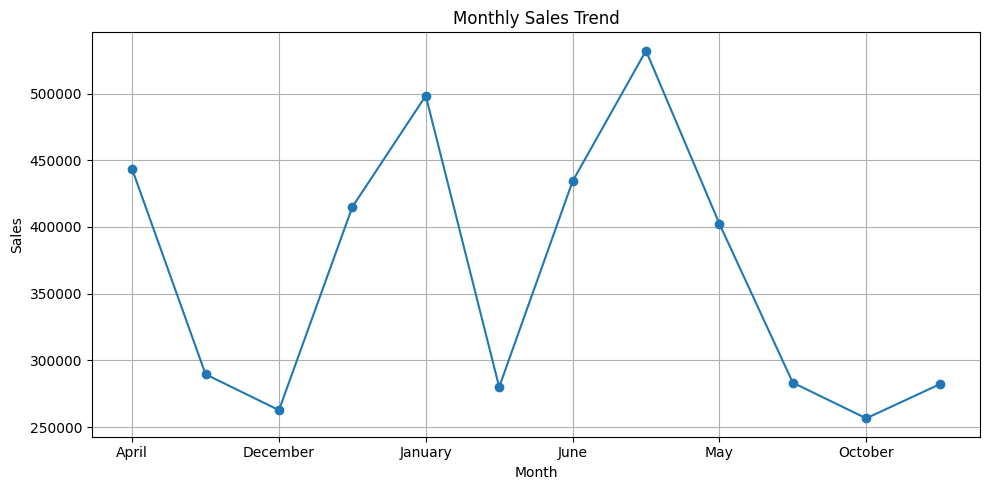

In [ ]:
# Monthly Sales

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

print(monthly_sales)

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)

plt.tight_layout()

plt.show()

**Profit Analysis**

Product
Chair      617255.6180
Desk       549614.7945
Laptop     677979.8015
Monitor    645807.1425
Phone      491871.9810
Printer    678520.7355
Tablet     677681.4155
Name: Profit, dtype: float64


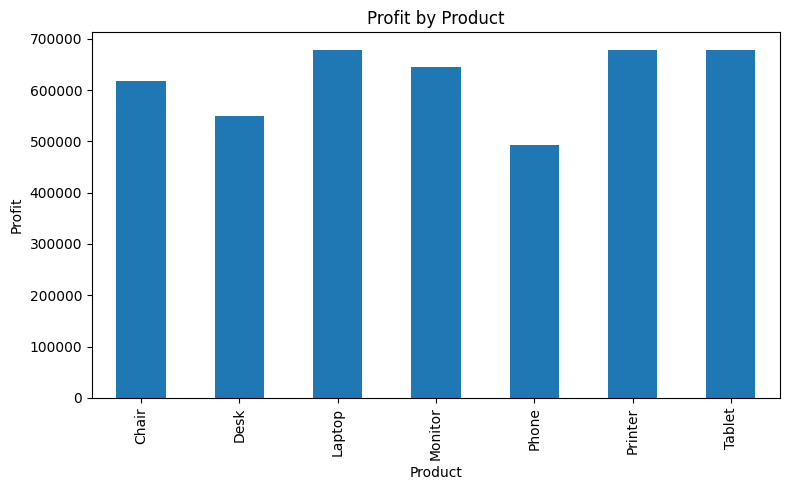

In [ ]:
# Profit Analysis
df['Profit'] = df['TotalPrice'] - df['ShippingCost']

profit_analysis = df.groupby('Product')['Profit'].sum()

print(profit_analysis)

plt.figure(figsize=(8,5))

profit_analysis.plot(kind='bar')

plt.title('Profit by Product')
plt.xlabel('Product')
plt.ylabel('Profit')

plt.tight_layout()

plt.show()

**Product Analysis**

Product
Chair      622589.4780
Desk       555266.6645
Laptop     684417.2415
Monitor    651629.3925
Phone      497162.8510
Printer    684387.4155
Tablet     684539.3855
Name: TotalPrice, dtype: float64


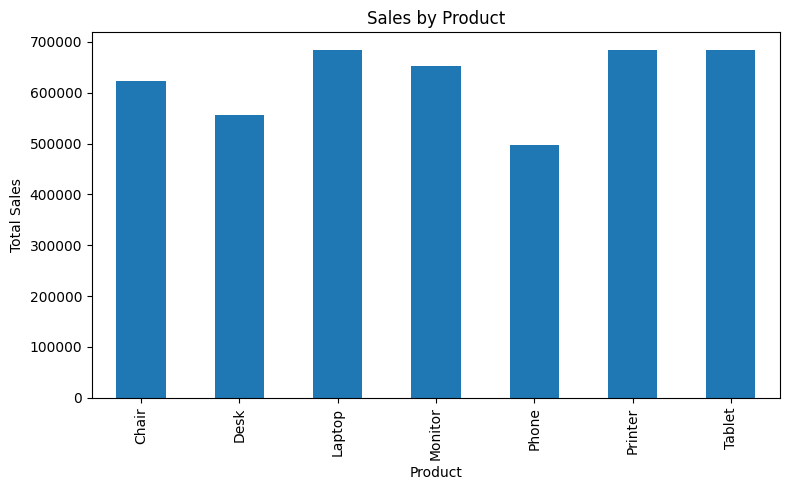

In [ ]:
# Product Sales Analysis

product_sales = df.groupby('Product')['TotalPrice'].sum()

print(product_sales)

plt.figure(figsize=(8,5))

product_sales.plot(kind='bar')

plt.title('Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.show()

**Statistical Analysis**

In [ ]:
# NumPy Statistics

print('Average Sales:', np.mean(df['TotalPrice']))

print('Maximum Sales:', np.max(df['TotalPrice']))

print('Minimum Sales:', np.min(df['TotalPrice']))

print('Standard Deviation:', np.std(df['TotalPrice']))

Average Sales: 2919.9949523333335
Maximum Sales: 11077.0
Minimum Sales: 6.969999999999999
Standard Deviation: 2521.9489066695223


**Correlation Analysis**

In [ ]:
# Correlation

correlation = df[['TotalPrice', 'Quantity', 'ShippingCost', 'Discount']].corr()

print(correlation)

              TotalPrice  Quantity  ShippingCost  Discount
TotalPrice      1.000000  0.666459     -0.009637 -0.059903
Quantity        0.666459  1.000000     -0.017973  0.017660
ShippingCost   -0.009637 -0.017973      1.000000 -0.030558
Discount       -0.059903  0.017660     -0.030558  1.000000


In [ ]:
# Save Cleaned Data

df.to_excel('Cleaned_Sales_Data.xlsx', index=False)

print('Project Completed Successfully')

Project Completed Successfully
